In [51]:
import pickle

from experiments.end_to_end.proof_node import ErrorNode
import torch
from torchmetrics.functional import pairwise_cosine_similarity
from transformers import AutoTokenizer, T5ForQuestionAnswering, T5ForConditionalGeneration
from transformers import T5EncoderModel


In [2]:


def get_tac_encodings(
        encoder, input_ids: torch.LongTensor, attention_mask: torch.LongTensor, tactic_lens
) -> torch.FloatTensor:
    # encode all tokens with tactic included
    combined_enc = encoder(input_ids, attention_mask, return_dict=True).last_hidden_state

    # get the tactic embeddings and mean pool them using the provided lengths
    tac_enc = []

    for i in range(combined_enc.shape[0]):
        enc = combined_enc[i, :tactic_lens[i]]
        enc = enc.sum(dim=0) / tactic_lens[i]
        enc = F.normalize(enc, dim=0)
        tac_enc.append(enc)

    tac_enc = torch.stack(tac_enc, dim=0).unsqueeze(1)
    return tac_enc


def get_vecs(encoder, tactics, goal, theorem):
    state = goal.data['augmented_state'] if hasattr(goal, 'data') and 'augmented_state' in goal.data else goal.goal

    encs = []

    # todo chunk into batches enc speedup
    for t in tactics:
        goal = [t + theorem + '\n\n' + state]

        tokenized_goals = tokenizer(
            goal,
            padding="longest",
            max_length=int(3000),
            truncation=True,
            return_tensors="pt", )

        tokenized_tactics = tokenizer(
            tactics,
            padding="longest",
            max_length=3000,
            truncation=True,
            return_tensors="pt",
        )

        lens = tokenized_tactics.attention_mask.sum(dim=1)

        enc = get_tac_encodings(encoder, tokenized_goals.input_ids.cuda(), tokenized_goals.attention_mask.cuda(),
                                lens.cuda())

        # scale enc by normalised tactic logprob
        # enc = enc * probs[tactics.index(t)]
        encs.append(enc.squeeze(0).squeeze(0))

    return torch.stack(encs, dim=0)


In [3]:

import torch.nn.functional as F


def _encode(
        encoder, input_ids: torch.LongTensor, attention_mask: torch.LongTensor
) -> torch.FloatTensor:
    hidden_states = encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        return_dict=True,
    ).last_hidden_state

    # Masked average.
    lens = attention_mask.sum(dim=1)
    features = (hidden_states * attention_mask.unsqueeze(2)).sum(
        dim=1
    ) / lens.unsqueeze(1)

    # Normalize the feature vector to have unit norm.
    return F.normalize(features, dim=1)


In [4]:

def plot(start, end, sims):
    # Convert the tensor to a NumPy array
    similarity_matrix_np = sims.cpu().detach().numpy()[start:end, start:end]

    names = tacs[start:end]
    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(similarity_matrix_np, xticklabels=names, yticklabels=names, annot=True, cmap='viridis')

    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Slant x-axis labels
    plt.xticks(rotation=45, ha='left')

    # Add labels and title
    plt.xlabel('Vectors')
    plt.ylabel('Vectors')
    plt.title('Pairwise Cosine Similarity Heatmap')

    # Display the heatmap
    plt.show()


In [5]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_overlay(start, end, sims1, sims2):
    # Convert the tensors to NumPy arrays
    similarity_matrix_np1 = sims1.cpu().detach().numpy()[start:end, start:end]
    similarity_matrix_np2 = sims2.cpu().detach().numpy()[start:end, start:end]

    names = tacs[start:end]

    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(similarity_matrix_np1, xticklabels=names, yticklabels=names, annot=False, cmap='viridis',
                     cbar=False)
    sns.heatmap(similarity_matrix_np2, xticklabels=names, yticklabels=names, annot=False, cmap='viridis', cbar=True,
                ax=ax)

    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Slant x-axis labels
    plt.xticks(rotation=45, ha='left')

    # Add diagonal splits and annotations
    for i in range(len(names)):
        for j in range(len(names)):
            value1 = similarity_matrix_np1[i, j]
            value2 = similarity_matrix_np2[i, j]

            # Add diagonal line
            # ax.add_patch(patches.Polygon([(j, i), (j+1, i), (j, i+1)], closed=True, fill=True, color='blue', alpha=0.3))
            # ax.add_patch(patches.Polygon([(j+1, i), (j+1, i+1), (j, i+1)], closed=True, fill=True, color='red', alpha=0.3))

            ax.add_patch(patches.Polygon([(j, i), (j + 1, i), (j, i + 1)], closed=True, fill=True,
                                         facecolor=plt.cm.viridis(value1), alpha=0.3))
            ax.add_patch(patches.Polygon([(j + 1, i), (j + 1, i + 1), (j, i + 1)], closed=True, fill=True,
                                         facecolor=plt.cm.viridis(value2), alpha=0.3))
            # Add annotations
            ax.text(j + 0.25, i + 0.25, f'{value1:.2f}', ha='center', va='center', fontsize=8, color='white')
            ax.text(j + 0.75, i + 0.75, f'{value2:.2f}', ha='center', va='center', fontsize=8, color='white')

    # Add labels and title
    plt.xlabel('Tactic')
    plt.ylabel('Tactic')
    plt.title('Overlay Pairwise Cosine Similarity Heatmap')

    # Display the heatmap
    plt.show()

# Example usage
# plot_overlay(start, end, sims1, sims2)


In [40]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_overlay_2(inds, sims1, sims2):
    # Convert the tensors to NumPy arrays
    similarity_matrix_np1 = sims1.cpu().detach().numpy()[inds][:, inds]
    similarity_matrix_np2 = sims2.cpu().detach().numpy()[inds][:, inds]
     
    
    print (similarity_matrix_np2)
    print (similarity_matrix_np2.shape)

    names = [tacs[i] for i in inds]

    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(similarity_matrix_np1, xticklabels=names, yticklabels=names, annot=False, cmap='viridis',
                     cbar=False)
    sns.heatmap(similarity_matrix_np2, xticklabels=names, yticklabels=names, annot=False, cmap='viridis', cbar=True,
                ax=ax)

    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Slant x-axis labels
    plt.xticks(rotation=45, ha='left')

    # Add diagonal splits and annotations
    for i in range(len(names)):
        for j in range(len(names)):
            value1 = similarity_matrix_np1[i, j]
            value2 = similarity_matrix_np2[i, j]

            # Add diagonal line
            # ax.add_patch(patches.Polygon([(j, i), (j+1, i), (j, i+1)], closed=True, fill=True, color='blue', alpha=0.3))
            # ax.add_patch(patches.Polygon([(j+1, i), (j+1, i+1), (j, i+1)], closed=True, fill=True, color='red', alpha=0.3))

            ax.add_patch(patches.Polygon([(j, i), (j + 1, i), (j, i + 1)], closed=True, fill=True,
                                         facecolor=plt.cm.viridis(value1), alpha=0.3))
            ax.add_patch(patches.Polygon([(j + 1, i), (j + 1, i + 1), (j, i + 1)], closed=True, fill=True,
                                         facecolor=plt.cm.viridis(value2), alpha=0.3))
            # Add annotations
            ax.text(j + 0.25, i + 0.25, f'{value1:.2f}', ha='center', va='center', fontsize=8, color='white')
            ax.text(j + 0.75, i + 0.75, f'{value2:.2f}', ha='center', va='center', fontsize=8, color='white')

    # Add labels and title
    plt.xlabel('Tactic')
    plt.ylabel('Tactic')
    plt.title('Overlay Pairwise Cosine Similarity Heatmap')

    # Display the heatmap
    plt.show()

# Example usage
# plot_overlay(start, end, sims1, sims2)


In [6]:
# separate_encoder_path = '../runs/separate_tac_encoder/checkpoints/separate_last.ckpt'

autoenc_path = '../runs/diversity/autoencoder/2024_07_18/12_13/checkpoints/autoencoder.ckpt'

combined_error_path = '../runs/error_pred/combined_transition_model/combined_minif2f_valid.ckpt'

ckpt = torch.load(combined_error_path)
state_dict = {k[12:]: v for k, v in ckpt.items() if k.startswith('tac_encoder')}

error_encoder = T5EncoderModel.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
                                               state_dict=state_dict).cuda()

# ckpt = torch.load(separate_encoder_path)
# state_dict = {k[12:]: v for k, v in ckpt.items() if k.startswith('tac_encoder')}
# separate_encoder = T5EncoderModel.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
#                                                   state_dict=state_dict).cuda()


ckpt = torch.load(autoenc_path)

state_dict = {k[12:]: v for k, v in ckpt.items() if k.startswith('tac_encoder')}

autoencoder = T5EncoderModel.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
                                             state_dict=state_dict).cuda()



In [7]:

state_dict = {k[8:]: v for k, v in ckpt.items() if k.startswith('decoder')}

autoenc_dec = T5ForConditionalGeneration.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
                                                         state_dict=state_dict).cuda()


In [8]:
tokenizer = AutoTokenizer.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises')


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [9]:

score_network = torch.nn.Sequential(
    torch.nn.Linear(error_encoder.config.d_model, error_encoder.config.d_model // 2),
    torch.nn.LayerNorm(error_encoder.config.d_model // 2),
    torch.nn.ReLU(),
    torch.nn.Linear(error_encoder.config.d_model // 2, 2),
)

ckpt = torch.load(combined_error_path)
state_dict = {k[14:]: v for k, v in ckpt.items() if k.startswith('score_network')}

score_network.load_state_dict(state_dict)


<All keys matched successfully>

In [10]:
score_network.to('cuda')

Sequential(
  (0): Linear(in_features=1472, out_features=736, bias=True)
  (1): LayerNorm((736,), eps=1e-05, elementwise_affine=True)
  (2): ReLU()
  (3): Linear(in_features=736, out_features=2, bias=True)
)

In [56]:

# good example with node 0
test_trace = '../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/aime_1988_p3'
# test_trace = '../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/algebra_manipexpr_apbeq2cceqiacpbceqm2'
# test_trace = "../runs/minif2f/fixed_no_score-k16/2024_08_28/16_02_42/traces/0/algebra_manipexpr_apbeq2cceqiacpbceqm2"

# test_trace = "../runs/bestfs-novel-2/cau_seq.lim_inv"

trace = pickle.load(open(test_trace, 'rb'))
nodes = list(trace.nodes.values())

In [69]:
# 2
node = nodes[0]
tacs = [e.tactic for e in node.out_edges]
theorem = trace.theorem.full_name

with torch.no_grad():
    error_encs = get_vecs(error_encoder, tacs, node, theorem)
    tokenized_tacs = [tokenizer(e,
                                padding="longest",
                                max_length=2300,
                                truncation=True,
                                return_tensors="pt") for e in tacs]

    lens = [tokenized_tactic.attention_mask.sum(dim=1) for tokenized_tactic in tokenized_tacs]

    # vecs = [_encode(separate_encoder, tac.input_ids.cuda(), tac.attention_mask.cuda())[0] for tac in tokenized_tacs]
    # separate_encs = torch.stack(vecs)

    autoencs = [_encode(autoencoder, tac.input_ids.cuda(), tac.attention_mask.cuda())[0] for tac in tokenized_tacs]

    autoencs = torch.stack(autoencs)

# separate_cosine_sim = pairwise_cosine_similarity(separate_encs)


error_cosine_sim = pairwise_cosine_similarity(error_encs)
autoencsim = pairwise_cosine_similarity(autoencs)


In [16]:
# scores = score_network(error_encs)
# 
# error_preds = torch.sigmoid(scores[:, 0])
# time_scores = scores[:, 1]
# 
# # normalise time scores
# 
# time_scores = F.normalize(time_scores, dim=-1, p=2)
# time_scores = 1 - time_scores



In [ ]:
# time_scores

In [76]:
subgoals = {}
for i, n in enumerate(node.out_edges):
    for sg in n.dst:
        if not isinstance(sg, ErrorNode):
            if sg not in subgoals:
                subgoals[sg] = [(i, n.tactic)]
            else:
                subgoals[sg].append((i, n.tactic))
                
        elif isinstance(sg, ErrorNode):
            if sg.inner.message not in subgoals:
                subgoals[sg.inner.message]  = [(i, n.tactic)]
            else:
                subgoals[sg.inner.message].append((i, n.tactic))
                
                
for k,v in subgoals.items():
    for i, x in enumerate(v):
        for j in range(i+1, len(v)):
            print (v[i], v[j])
            print (autoencsim[v[i][0], v[j][0]].item())
            print (error_cosine_sim[v[i][0], v[j][0]].item())


(0, 'simp') (1, 'norm_num')
0.6210682392120361
0.8613868951797485
(0, 'simp') (4, 'simp [h₀]')
0.6026371121406555
0.7970386743545532
(0, 'simp') (5, "simp [h₀.ne']")
0.49067938327789307
0.8295378088951111
(0, 'simp') (10, 'simp [h₀, h₁]')
0.5302419066429138
0.7894980907440186
(0, 'simp') (15, 'simp [<a>sq_abs</a>]')
0.5793038606643677
0.7817375063896179
(0, 'simp') (26, "simp [h₀.ne', h₀.ne']")
0.4009822905063629
0.7860540747642517
(0, 'simp') (31, 'simp [<a>abs_of_pos</a> h₀]')
0.441079705953598
0.7650418281555176
(0, 'simp') (34, 'rw [<a>abs_of_pos</a> h₀, <a>abs_of_pos</a> h₀]')
0.36172711849212646
0.2993059456348419
(0, 'simp') (35, "simp [h₀.ne', h₁]")
0.4764918088912964
0.8217555284500122
(0, 'simp') (55, 'simp [<a>abs_of_pos</a> h₀, <a>abs_of_pos</a> h₀]')
0.3639810085296631
0.7927356958389282
(0, 'simp') (57, 'rw [<a>abs_of_pos</a> h₀, <a>real.logb_abs</a>]')
0.386156290769577
0.2821497917175293
(1, 'norm_num') (4, 'simp [h₀]')
0.6045747995376587
0.744424045085907
(1, 'norm_num

In [50]:

for i, e in enumerate(node.out_edges):
    print(i, e)

0 Edge(tactic='linarith', tac_logprob=-2.248565196990967, goal_logprob=0.0, time=0.742322196951136)
1 Edge(tactic='exfalso', tac_logprob=-3.7833616733551025, goal_logprob=0.0, time=0.38887947995681316)
2 Edge(tactic='norm_num at h₀', tac_logprob=-4.053168773651123, goal_logprob=0.0, time=4.921205084072426)
3 Edge(tactic='simpa using h₀', tac_logprob=-4.3160624504089355, goal_logprob=0.0, time=5.079014204093255)
4 Edge(tactic='norm_num at h₀ h₁', tac_logprob=-4.413327693939209, goal_logprob=0.0, time=5.010152391041629)
5 Edge(tactic='norm_num at h₁', tac_logprob=-4.753101825714111, goal_logprob=0.0, time=4.295722658978775)
6 Edge(tactic='convert h₀', tac_logprob=-5.51590633392334, goal_logprob=0.0, time=2.6036483130883425)
7 Edge(tactic='norm_num at *', tac_logprob=-5.517383098602295, goal_logprob=0.0, time=5.911450876970775)
8 Edge(tactic='apply <a>le_antisymm</a>', tac_logprob=-5.533993721008301, goal_logprob=0.0, time=1.0024675809545442)
9 Edge(tactic='ring', tac_logprob=-5.572265148

In [19]:
print(node.out_edges[9].dst)
print(node.out_edges[12].dst)


[InternalNode(goal='a b c : ℂ,\nh₁ : c = complex.I\n⊢ a * c + b * c = -2', _status=<Status.OPEN: 'Open'>)]
[InternalNode(goal='a b c : ℂ,\nh₀ : a + b = 2 * c,\nh₁ : c = complex.I\n⊢ -2 = a * c + b * c', _status=<Status.PROVED: 'Proved'>)]


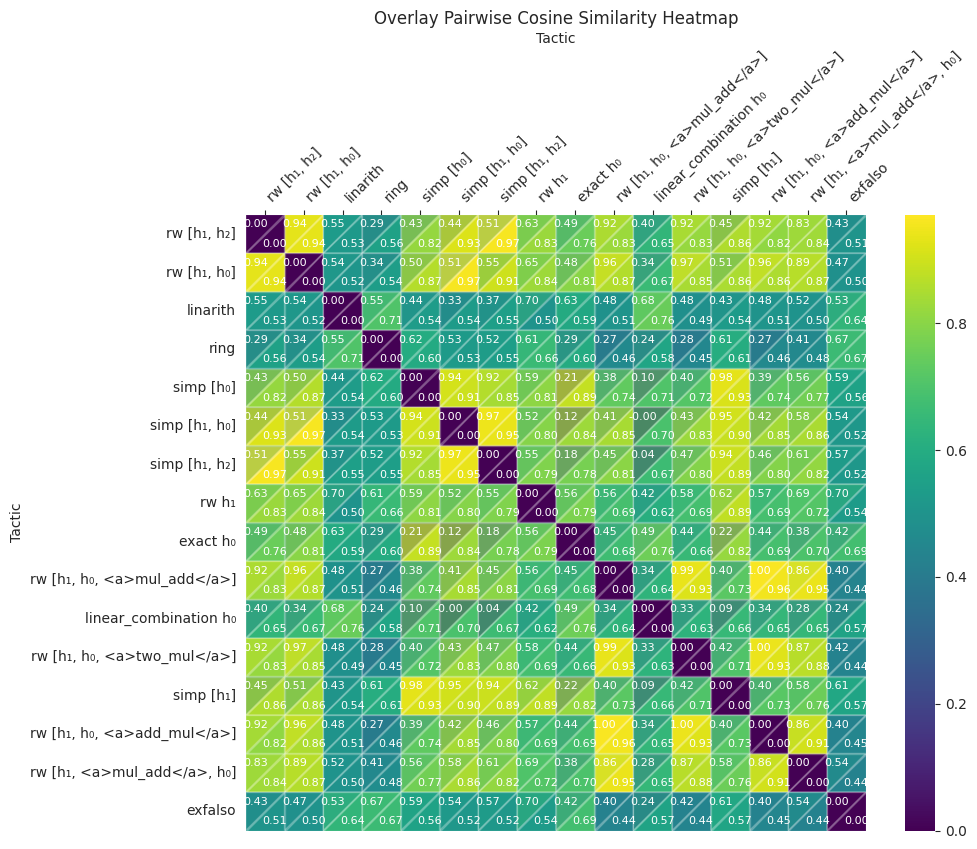

In [42]:
from experiments.end_to_end.proof_node import ErrorNode

start = 0
end = 16

names = tacs[start:end]
gt = node.out_edges[start:end]

# for x in [(i + start, names[i], round(error_preds[i].item(),2), 0 if type(gt[i].dst[0]) == ErrorNode else 1, time_scores[i].item(), gt[i].time, ) for i in range(len(names))]:
#     print (x)

# print (node.data['augmented_state'])
plot_overlay(start, end, error_cosine_sim, autoencsim)
# plot_overlay(start, end, error_cosine_sim, time_scores.unsqueeze(1))


# plot_overlay(start, end, autoencsim, combined_cosine_sim)

[[0.         0.86314815 0.5754169  0.5641482  0.83108455]
 [0.86314815 0.         0.6540023  0.6406484  0.88684386]
 [0.5754169  0.6540023  0.         0.6807246  0.618347  ]
 [0.5641482  0.6406484  0.6807246  0.         0.57056725]
 [0.83108455 0.88684386 0.618347   0.57056725 0.        ]]
(5, 5)


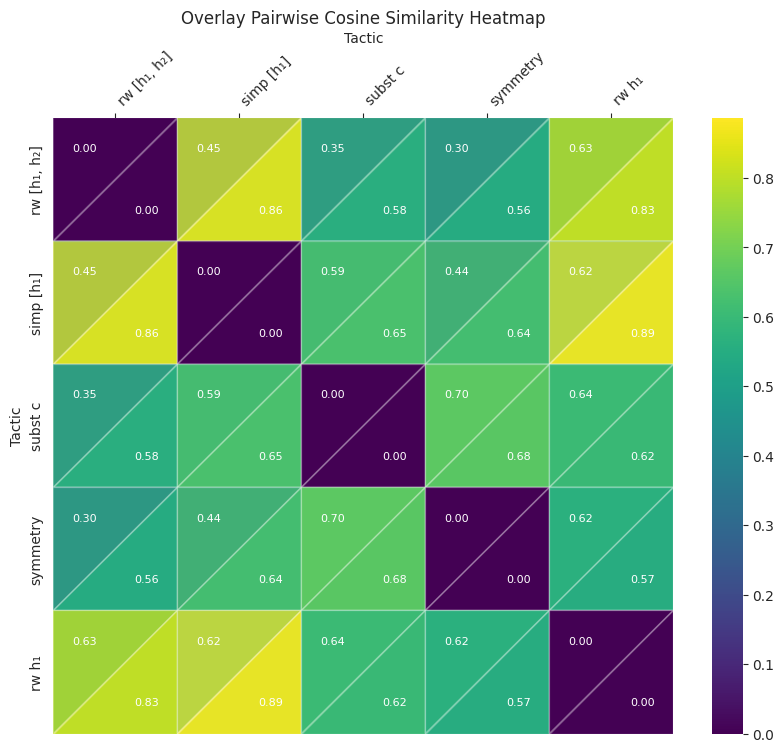

In [43]:
inds = [0, 12, 30, 45, 7]
from experiments.end_to_end.proof_node import ErrorNode

start = 0
end = 16

names = [tacs[i] for  i in inds]
gt = [node.out_edges[i] for i in inds]

# for x in [(i + start, names[i], round(error_preds[i].item(),2), 0 if type(gt[i].dst[0]) == ErrorNode else 1, time_scores[i].item(), gt[i].time, ) for i in range(len(names))]:
#     print (x)

# print (node.data['augmented_state'])
plot_overlay_2(inds, error_cosine_sim, autoencsim)
# plot_overlay(start, end, error_cosine_sim, time_scores.unsqueeze(1))


# plot_overlay(start, end, autoencsim, combined_cosine_sim)